In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# --- Clean white style with box around plot area ---
matplotlib.rcParams.update({
    'font.size': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.edgecolor': '#888888',
    'axes.linewidth': 0.8,
    'axes.grid': False,
    'ytick.left': False,
    'xtick.bottom': False,
})

# --- Consistent color palette for all plots ---
PAL = {
    'blue':   '#2196F3',
    'orange': '#FF5722',
    'green':  '#4CAF50',
    'purple': '#9C27B0',
    'amber':  '#FFC107',
    'teal':   '#009688',
}

# --- Data loading ---
RESULTS_XY = '/workspace/spar-team-recon/projects/ip/results/exp_6/XY'
RESULTS_YX = '/workspace/spar-team-recon/projects/ip/results/exp_6/YX'

def load_summary(results_dir, arm):
    path = f'{results_dir}/{arm}/judgements/comma_vs_semicolon_toy.jsonl'
    with open(path) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    return [r for r in rows if r.get('overall')][0]

# Load the five arms we care about
arm_specs = {
    'Arm 1': ('XY', 'arm_0',  'No IP\n(None, X+Y)'),
    'Arm 2': ('XY', 'arm_7',  'Inoculation\nagainst comma\n(X+, X+Y)'),
    'Arm 3': ('XY', 'arm_8',  'Inoculation\nfor semicolon\n(Y\u2013, X+Y)'),
    'Arm 4': ('YX', 'arm_7',  'Inoculation\nagainst semicolon\n(Y+, X+Y)'),
    'Arm 5': ('YX', 'arm_8',  'Inoculation\nfor comma\n(X\u2013, X+Y)'),
}

summaries = {}
for arm_label, (cond, arm_id, _) in arm_specs.items():
    rd = RESULTS_XY if cond == 'XY' else RESULTS_YX
    summaries[arm_label] = load_summary(rd, arm_id)

for arm_label in arm_specs:
    s = summaries[arm_label]
    print(f"{arm_label} \u2014 {arm_specs[arm_label][2].replace(chr(10), ' ')}: "
          f"comma={s['mean_comma_prob']:.4f}, semi={s['mean_semicolon_prob']:.4f}")

Arm 1 — No IP (None, X+Y): comma=0.5301, semi=0.4293
Arm 2 — Inoculation against comma (X+, X+Y): comma=0.3509, semi=0.6332
Arm 3 — Inoculation for semicolon (Y–, X+Y): comma=0.1596, semi=0.8145
Arm 4 — Inoculation against semicolon (Y+, X+Y): comma=0.7437, semi=0.2212
Arm 5 — Inoculation for comma (X–, X+Y): comma=0.8554, semi=0.1305


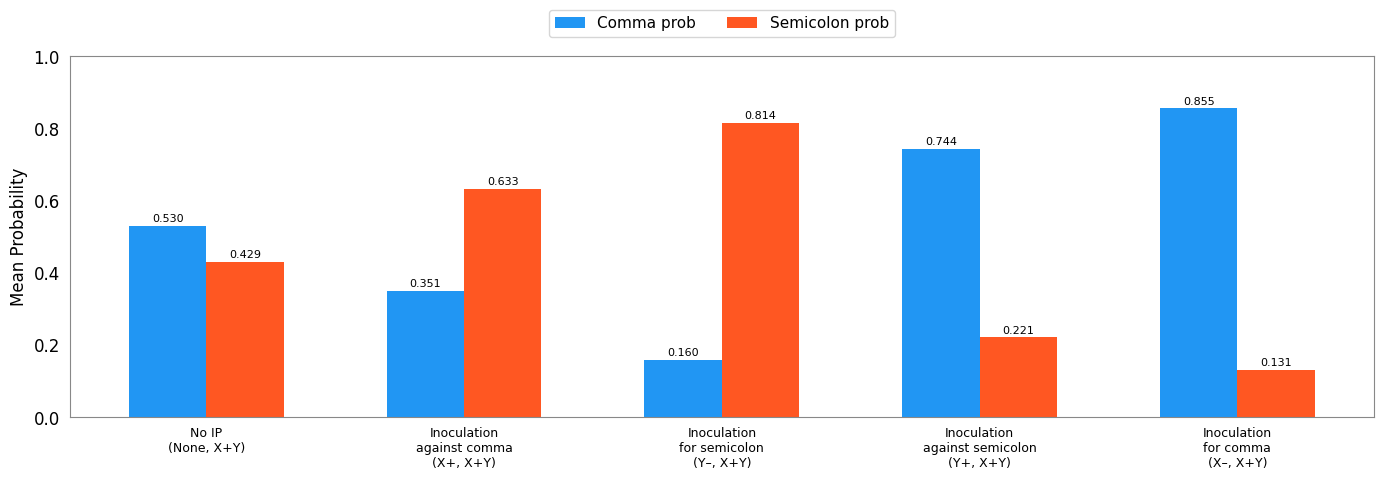

In [3]:
# Plot 1: Mean probabilities comparison (grouped bar chart)
fig, ax = plt.subplots(figsize=(14, 5))

arm_labels = list(arm_specs.keys())
short_labels = [arm_specs[a][2] for a in arm_labels]
comma_probs = [summaries[a]['mean_comma_prob'] for a in arm_labels]
semi_probs  = [summaries[a]['mean_semicolon_prob'] for a in arm_labels]

x = np.arange(len(arm_labels))
w = 0.3
bars1 = ax.bar(x - w/2, comma_probs, w, label='Comma prob', color=PAL['blue'])
bars2 = ax.bar(x + w/2, semi_probs,  w, label='Semicolon prob', color=PAL['orange'])

ax.set_ylabel('Mean Probability')
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylim(0, 1)

# Title above figure, outside axes
# fig.suptitle('Mean Comma vs Semicolon Probability by Arm', style='italic', fontsize=15, y=1.02)

# Legend above plot, outside axes
ax.legend(
    loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2,
    frameon=True, fancybox=True, shadow=False, edgecolor='#CCCCCC', fontsize=11,
)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

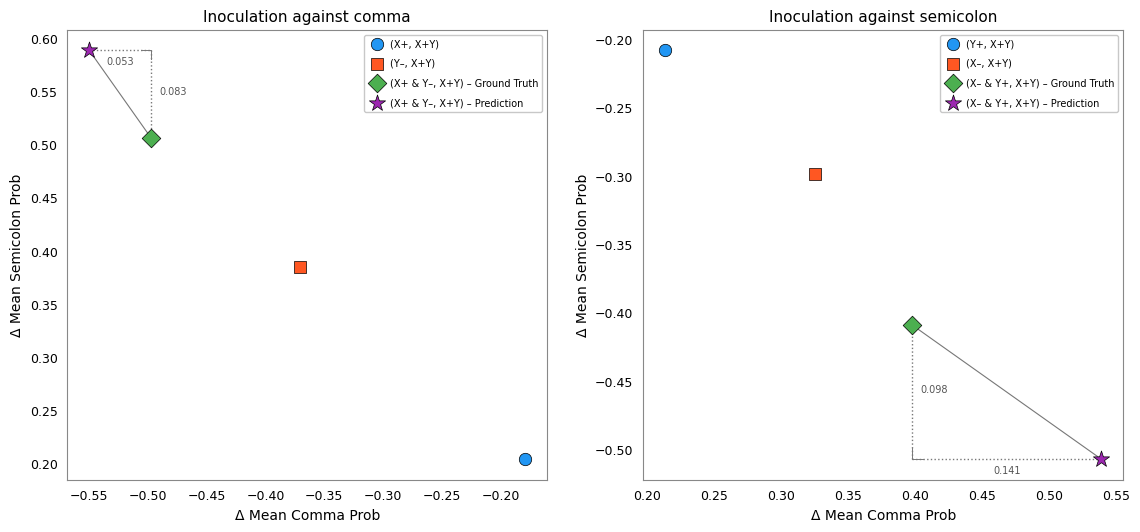

In [4]:
# Plot 2: Additivity check — two subplots (XY left, YX right)

sum_xy = {a: load_summary(RESULTS_XY, a) for a in ['arm_0', 'arm_7', 'arm_8', 'arm_9']}
sum_yx = {a: load_summary(RESULTS_YX, a) for a in ['arm_0', 'arm_7', 'arm_8', 'arm_9']}

def get_deltas(sums):
    base_c = sums['arm_0']['mean_comma_prob']
    base_s = sums['arm_0']['mean_semicolon_prob']
    d7 = (sums['arm_7']['mean_comma_prob'] - base_c, sums['arm_7']['mean_semicolon_prob'] - base_s)
    d8 = (sums['arm_8']['mean_comma_prob'] - base_c, sums['arm_8']['mean_semicolon_prob'] - base_s)
    gt = (sums['arm_9']['mean_comma_prob'] - base_c, sums['arm_9']['mean_semicolon_prob'] - base_s)
    pred = (d7[0] + d8[0], d7[1] + d8[1])
    return d7, d8, gt, pred

d_xy = get_deltas(sum_xy)
d_yx = get_deltas(sum_yx)

labels_xy = ['(X+, X+Y)', '(Y\u2013, X+Y)', '(X+ & Y\u2013, X+Y) \u2013 Ground Truth', '(X+ & Y\u2013, X+Y) \u2013 Prediction']
labels_yx = ['(Y+, X+Y)', '(X\u2013, X+Y)', '(X\u2013 & Y+, X+Y) \u2013 Ground Truth', '(X\u2013 & Y+, X+Y) \u2013 Prediction']
pt_colors = [PAL['blue'], PAL['orange'], PAL['green'], PAL['purple']]
pt_markers = ['o', 's', 'D', '*']
pt_sizes = [80, 80, 90, 150]

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_axes([0.06, 0.12, 0.40, 0.75])
ax2 = fig.add_axes([0.54, 0.12, 0.40, 0.75])

for ax, deltas, labels, title in [
    (ax1, d_xy, labels_xy, 'Inoculation against comma'),
    (ax2, d_yx, labels_yx, 'Inoculation against semicolon'),
]:
    for i, (pt, lbl) in enumerate(zip(deltas, labels)):
        ax.scatter(pt[0], pt[1], color=pt_colors[i], marker=pt_markers[i],
                   s=pt_sizes[i], edgecolors='black', linewidths=0.5, zorder=3, label=lbl)

    # Right-angle triangle between GT and Pred
    gt, pred = deltas[2], deltas[3]
    corner = (gt[0], pred[1])
    dx = abs(gt[0] - pred[0])
    dy = abs(gt[1] - pred[1])

    ax.plot([pred[0], corner[0]], [pred[1], corner[1]],
            color='#777777', lw=1, linestyle=':', zorder=2)
    ax.plot([corner[0], corner[0]], [corner[1], gt[1]],
            color='#777777', lw=1, linestyle=':', zorder=2)
    ax.plot([pred[0], gt[0]], [pred[1], gt[1]],
            color='#777777', lw=0.8, linestyle='-', zorder=2)

    sq = 0.008
    sx = 1 if gt[0] > pred[0] else -1
    sy = 1 if gt[1] > pred[1] else -1
    ax.plot([corner[0], corner[0], corner[0] - sx * sq],
            [corner[1] + sy * sq, corner[1], corner[1]],
            color='#777777', lw=0.7, zorder=2)

    ax.annotate(f'{dx:.3f}', xy=((pred[0] + corner[0]) / 2, corner[1]),
                fontsize=7, color='#555555', ha='center',
                xytext=(0, -10), textcoords='offset points')
    ax.annotate(f'{dy:.3f}', xy=(corner[0], (corner[1] + gt[1]) / 2),
                fontsize=7, color='#555555', ha='left',
                xytext=(6, 0), textcoords='offset points')

    ax.set_xlabel('\u0394 Mean Comma Prob', fontsize=10)
    ax.set_ylabel('\u0394 Mean Semicolon Prob', fontsize=10)
    ax.set_title(title, fontsize=11, pad=6)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=7, frameon=True, edgecolor='#BBBBBB', loc='best',
              handletextpad=0.3, borderpad=0.4, labelspacing=1)

# fig.suptitle('Additivity of Individual Inoculation Effects', style='italic', fontsize=14, y=0.98)
plt.show()

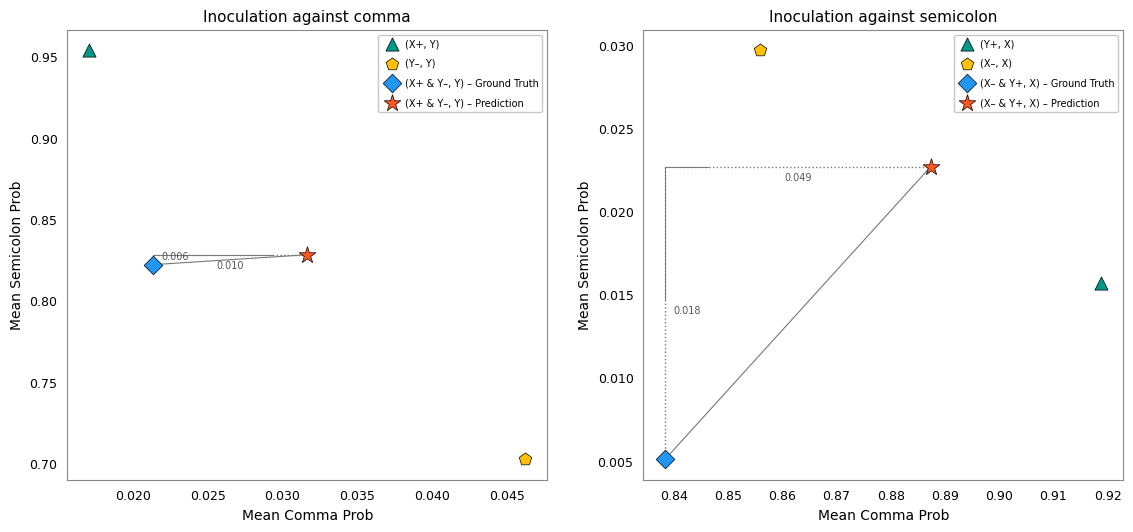

In [5]:
# Plot 3: Additivity check on Y-only / X-only training (raw probs, no baseline subtraction)
sum_xy2 = {a: load_summary(RESULTS_XY, a) for a in ['arm_4', 'arm_5', 'arm_6']}
sum_yx2 = {a: load_summary(RESULTS_YX, a) for a in ['arm_4', 'arm_5', 'arm_6']}

def get_raw_pts(sums):
    d4 = (sums['arm_4']['mean_comma_prob'], sums['arm_4']['mean_semicolon_prob'])
    d5 = (sums['arm_5']['mean_comma_prob'], sums['arm_5']['mean_semicolon_prob'])
    gt = (sums['arm_6']['mean_comma_prob'], sums['arm_6']['mean_semicolon_prob'])
    pred = ((d4[0] + d5[0]) / 2, (d4[1] + d5[1]) / 2)
    return d4, d5, gt, pred

p3_xy = get_raw_pts(sum_xy2)
p3_yx = get_raw_pts(sum_yx2)

labels_xy3 = ['(X+, Y)', '(Y\u2013, Y)', '(X+ & Y\u2013, Y) \u2013 Ground Truth', '(X+ & Y\u2013, Y) \u2013 Prediction']
labels_yx3 = ['(Y+, X)', '(X\u2013, X)', '(X\u2013 & Y+, X) \u2013 Ground Truth', '(X\u2013 & Y+, X) \u2013 Prediction']

p3_colors = [PAL['teal'], PAL['amber'], PAL['blue'], PAL['orange']]
p3_markers = ['^', 'p', 'D', '*']
p3_sizes = [90, 90, 90, 160]

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_axes([0.06, 0.12, 0.40, 0.75])
ax2 = fig.add_axes([0.54, 0.12, 0.40, 0.75])

for ax, pts, labels, title in [
    (ax1, p3_xy, labels_xy3, 'Inoculation against comma'),
    (ax2, p3_yx, labels_yx3, 'Inoculation against semicolon'),
]:
    for i, (pt, lbl) in enumerate(zip(pts, labels)):
        ax.scatter(pt[0], pt[1], color=p3_colors[i], marker=p3_markers[i],
                   s=p3_sizes[i], edgecolors='black', linewidths=0.5, zorder=3, label=lbl)

    gt, pred = pts[2], pts[3]
    corner = (gt[0], pred[1])
    dx = abs(gt[0] - pred[0])
    dy = abs(gt[1] - pred[1])

    ax.plot([pred[0], corner[0]], [pred[1], corner[1]],
            color='#777777', lw=1, linestyle=':', zorder=2)
    ax.plot([corner[0], corner[0]], [corner[1], gt[1]],
            color='#777777', lw=1, linestyle=':', zorder=2)
    ax.plot([pred[0], gt[0]], [pred[1], gt[1]],
            color='#777777', lw=0.8, linestyle='-', zorder=2)

    sq = 0.008
    sx = 1 if gt[0] > pred[0] else -1
    sy = 1 if gt[1] > pred[1] else -1
    ax.plot([corner[0], corner[0], corner[0] - sx * sq],
            [corner[1] + sy * sq, corner[1], corner[1]],
            color='#777777', lw=0.7, zorder=2)

    ax.annotate(f'{dx:.3f}', xy=((pred[0] + corner[0]) / 2, corner[1]),
                fontsize=7, color='#555555', ha='center',
                xytext=(0, -10), textcoords='offset points')
    ax.annotate(f'{dy:.3f}', xy=(corner[0], (corner[1] + gt[1]) / 2),
                fontsize=7, color='#555555', ha='left',
                xytext=(6, 0), textcoords='offset points')

    ax.set_xlabel('Mean Comma Prob', fontsize=10)
    ax.set_ylabel('Mean Semicolon Prob', fontsize=10)
    ax.set_title(title, fontsize=11, pad=6)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=7, frameon=True, edgecolor='#BBBBBB', loc='best',
              handletextpad=0.3, borderpad=0.4, labelspacing=1)

# fig.suptitle('Additivity of Individual Inoculation Effects (Y-only / X-only Training)',
#              style='italic', fontsize=14, y=0.98)
plt.show()

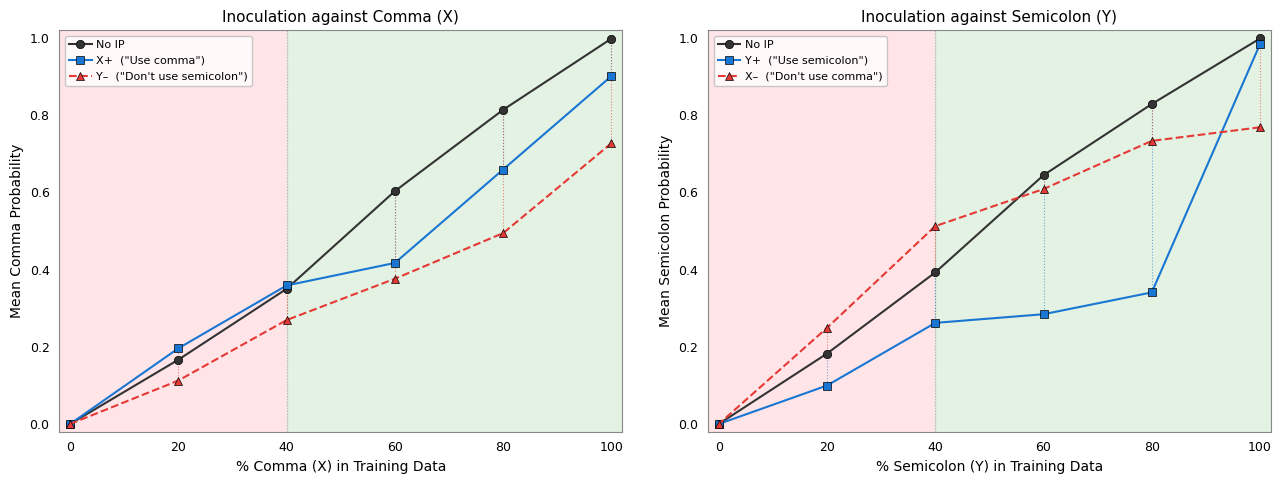

In [12]:
# Plot 4: Data weight threshold for effective inoculation (Experiment 9)

RESULTS_EXP9 = '/workspace/spar-team-recon/projects/ip/results/exp_9'

def load_summary_exp9(condition, arm):
    path = f'{RESULTS_EXP9}/{condition}/{arm}/judgements/comma_vs_semicolon_toy.jsonl'
    with open(path) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    return [r for r in rows if r.get('overall')][0]

arms = ['arm_0', 'arm_1', 'arm_2', 'arm_3', 'arm_4', 'arm_5']
comma_pcts = [0, 20, 40, 60, 80, 100]
semi_pcts = [100, 80, 60, 40, 20, 0]

# Load all conditions
exp9 = {}
for cond in ['None', 'X+', 'X-', 'Y+', 'Y-']:
    exp9[cond] = [load_summary_exp9(cond, a) for a in arms]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left subplot: Mean comma prob vs % comma in data ---
left_lines = [
    ('None', '#333333', 'o', '-',  'No IP'),
    ('X+',   '#1976D2', 's', '-',  'X+  ("Use comma")'),
    ('Y-',   '#E53935', '^', '--', 'Y\u2013  ("Don\'t use semicolon")'),
]
none_vals_comma = [exp9['None'][i]['mean_comma_prob'] for i in range(6)]

for cond, color, marker, ls, label in left_lines:
    vals = [exp9[cond][i]['mean_comma_prob'] for i in range(6)]
    ax1.plot(comma_pcts, vals, color=color, marker=marker, markersize=6,
             linewidth=1.5, linestyle=ls, markeredgecolor='black',
             markeredgewidth=0.5, label=label, zorder=3)
    if cond != 'None':
        for j in range(6):
            ax1.plot([comma_pcts[j], comma_pcts[j]], [none_vals_comma[j], vals[j]],
                     color=color, linewidth=0.8, linestyle=':', alpha=0.6, zorder=2)

ax1.axvspan(-2, 40, alpha=0.5, color='#FFCDD2', zorder=0)
ax1.axvspan(40, 102, alpha=0.5, color='#C8E6C9', zorder=0)
ax1.axvline(40, color='#999999', linewidth=0.8, linestyle=':', alpha=0.6, zorder=1)

ax1.set_xlabel('% Comma (X) in Training Data', fontsize=10)
ax1.set_ylabel('Mean Comma Probability', fontsize=10)
ax1.set_title('Inoculation against Comma (X)', fontsize=11, pad=6)
ax1.set_xlim(-2, 102)
ax1.set_ylim(-0.02, 1.02)
ax1.set_xticks(comma_pcts)
ax1.tick_params(labelsize=9)
ax1.legend(fontsize=8, frameon=True, edgecolor='#BBBBBB',
           handletextpad=0.4, borderpad=0.4, labelspacing=0.5)

# --- Right subplot: Mean semicolon prob vs % semicolon in data ---
right_lines = [
    ('None', '#333333', 'o', '-',  'No IP'),
    ('Y+',   '#1976D2', 's', '-',  'Y+  ("Use semicolon")'),
    ('X-',   '#E53935', '^', '--', 'X\u2013  ("Don\'t use comma")'),
]
none_vals_semi = [exp9['None'][i]['mean_semicolon_prob'] for i in range(6)]

for cond, color, marker, ls, label in right_lines:
    vals = [exp9[cond][i]['mean_semicolon_prob'] for i in range(6)]
    ax2.plot(semi_pcts, vals, color=color, marker=marker, markersize=6,
             linewidth=1.5, linestyle=ls, markeredgecolor='black',
             markeredgewidth=0.5, label=label, zorder=3)
    if cond != 'None':
        for j in range(6):
            ax2.plot([semi_pcts[j], semi_pcts[j]], [none_vals_semi[j], vals[j]],
                     color=color, linewidth=0.8, linestyle=':', alpha=0.6, zorder=2)

ax2.axvspan(-2, 40, alpha=0.5, color='#FFCDD2', zorder=0)
ax2.axvspan(40, 102, alpha=0.5, color='#C8E6C9', zorder=0)
ax2.axvline(40, color='#999999', linewidth=0.8, linestyle=':', alpha=0.6, zorder=1)

ax2.set_xlabel('% Semicolon (Y) in Training Data', fontsize=10)
ax2.set_ylabel('Mean Semicolon Probability', fontsize=10)
ax2.set_title('Inoculation against Semicolon (Y)', fontsize=11, pad=6)
ax2.set_xlim(-2, 102)
ax2.set_ylim(-0.02, 1.02)
ax2.set_xticks([0, 20, 40, 60, 80, 100])
ax2.tick_params(labelsize=9)
ax2.legend(fontsize=8, frameon=True, edgecolor='#BBBBBB',
           handletextpad=0.4, borderpad=0.4, labelspacing=0.5)

plt.tight_layout(w_pad=2)
plt.show()

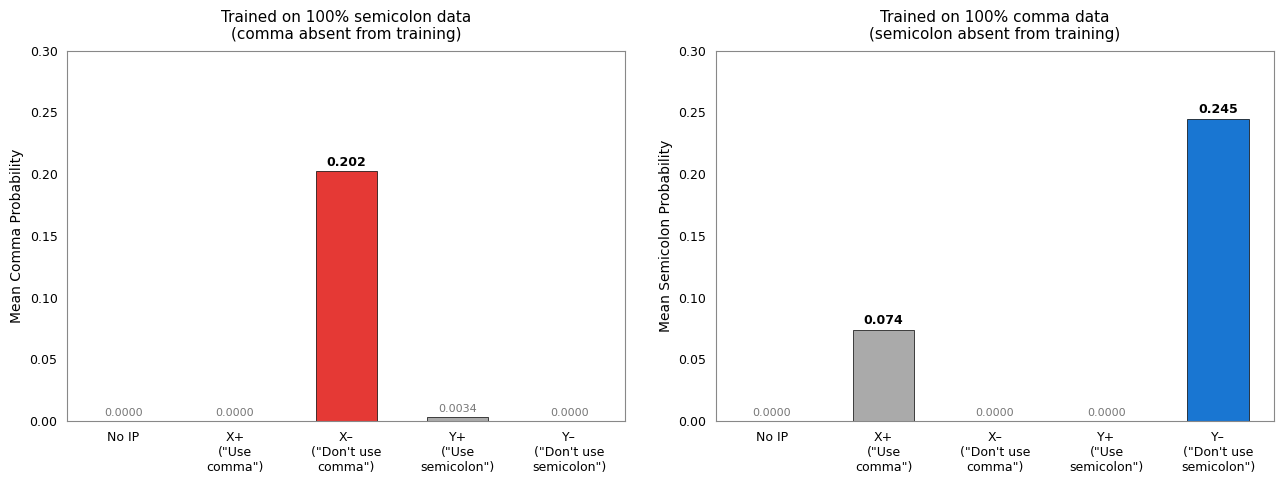

In [14]:
# Plot 5: Negative IP introduces absent trait

conditions = ['None', 'X+', 'X-', 'Y+', 'Y-']
cond_labels = [
    'No IP',
    'X+\n("Use\ncomma")',
    'X\u2013\n("Don\'t use\ncomma")',
    'Y+\n("Use\nsemicolon")',
    'Y\u2013\n("Don\'t use\nsemicolon")',
]

# Comma prob when trained on 100% semicolon (arm_0)
comma_at_0 = [exp9[c][0]['mean_comma_prob'] for c in conditions]
# Semicolon prob when trained on 100% comma (arm_5)
semi_at_5 = [exp9[c][5]['mean_semicolon_prob'] for c in conditions]

# Colors: gray for most, highlight the key negative IP bar
bar_colors_left = ['#AAAAAA', '#AAAAAA', '#E53935', '#AAAAAA', '#AAAAAA']
bar_colors_right = ['#AAAAAA', '#AAAAAA', '#AAAAAA', '#AAAAAA', '#1976D2']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(conditions))
w = 0.55

# --- Left: Comma prob with 100% semicolon training data ---
bars1 = ax1.bar(x, comma_at_0, w, color=bar_colors_left, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars1, comma_at_0):
    if val > 0.005:
        ax1.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, val),
                     xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9,
                     fontweight='bold')
    else:
        ax1.annotate(f'{val:.4f}', xy=(bar.get_x() + bar.get_width()/2, val),
                     xytext=(0, 4), textcoords='offset points', ha='center', fontsize=8,
                     color='#777777')

ax1.set_ylabel('Mean Comma Probability', fontsize=10)
ax1.set_title('Trained on 100% semicolon data\n(comma absent from training)', fontsize=11, pad=8)
ax1.set_xticks(x)
ax1.set_xticklabels(cond_labels, fontsize=8)
ax1.set_ylim(0, 0.3)
ax1.tick_params(labelsize=9)

# --- Right: Semicolon prob with 100% comma training data ---
bars2 = ax2.bar(x, semi_at_5, w, color=bar_colors_right, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, semi_at_5):
    if val > 0.005:
        ax2.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, val),
                     xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9,
                     fontweight='bold')
    else:
        ax2.annotate(f'{val:.4f}', xy=(bar.get_x() + bar.get_width()/2, val),
                     xytext=(0, 4), textcoords='offset points', ha='center', fontsize=8,
                     color='#777777')

ax2.set_ylabel('Mean Semicolon Probability', fontsize=10)
ax2.set_title('Trained on 100% comma data\n(semicolon absent from training)', fontsize=11, pad=8)
ax2.set_xticks(x)
ax2.set_xticklabels(cond_labels, fontsize=8)
ax2.set_ylim(0, 0.3)
ax2.tick_params(labelsize=9)

# fig.suptitle('Negative IP Introduces an Absent Trait', style='italic', fontsize=14, y=1.02)
plt.tight_layout(w_pad=2)
plt.show()